# WYR Data Analysis
Categorises model-generated question pairings by theme using a sentence-embedding model, then visualises category distributions and moderation (upvote / downvote / flag) scores.

## 1 · Imports & Setup

In [1]:
from sentence_transformers import SentenceTransformer
import hdbscan
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sqlite3
import pandas as pd
from tqdm.notebook import tqdm
from datetime import datetime
import matplotlib.colors as mcolors
import seaborn

TIME = datetime.today().strftime("%Y-%m-%d")
print(f"Run date: {TIME}")

Run date: 2026-06-26


## 2 · Embedding Model & Category Definitions

In [2]:
ST_MODEL = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
print("Sentence-transformer loaded.")

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

Sentence-transformer loaded.


In [3]:
CATEGORIES = {
    "animals":       ["animals", "pets", "creatures", "wildlife"],
    "body parts":    ["body parts", "limbs", "organs", "physical features", "arms", "legs"],
    "money":         ["money", "wealth", "finances", "$", "rich", "dollars", "currency"],
    "food / drink":  ["food", "drink", "eating", "meals", "cooking", "drinking"],
    "life":          ["life", "survival", "status", "well-being", "death", "dying",
                      "mortality", "afterlife", "living forever"],
    "ability":       ["superpower", "ability", "special ability", "magic power",
                      "power", "skill", "be able to"],
    "curse":         ["curse", "situation", "stuck", "trapped", "bewitched",
                      "inhibited", "rules", "forced"],
    "age / time":    ["age", "time", "youth", "old age", "going back in time"],
    "people":        ["people", "population", "persons", "everybody", "strangers",
                      "neighbors", "friends", "occupation", "job", "career"],
    "locations":     ["location", "countries", "cities", "towns", "world", "space"],
    "sentience":     ["become", "becoming", "inanimate", "transform", "stuck",
                      "mutation", "live as inanimate object", "be a", "be an"],
    "miscellaneous": ["miscellaneous", "other", "general", "random", "unrelated"],
}

MISC_THRESH = 0.50
print(f"{len(CATEGORIES)} categories defined.")

12 categories defined.


In [4]:
print("Pre-computing category embeddings...")
category_embeddings = {
    cat: ST_MODEL.encode(phrases)
    for cat, phrases in CATEGORIES.items()
}
print("Done.")

Pre-computing category embeddings...
Done.


## 3 · Helper Functions

In [5]:
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

In [6]:
def categorize_pairing(pairing):
    """Assign a main and secondary category to an option-A / option-B pairing."""
    combined        = f"{pairing['a']} or {pairing['b']}"
    query_embedding = ST_MODEL.encode(combined)

    best_category    = None
    best_score       = -1
    closest_category = "n/a"
    second_score     = 0

    for category, phrase_embeddings in category_embeddings.items():
        scores = [cosine_similarity(query_embedding, pe) for pe in phrase_embeddings]
        score  = max(scores)
        if score > best_score:
            closest_category = best_category
            second_score     = best_score
            best_score       = score
            best_category    = category
        elif second_score < score:
            closest_category = category
            second_score     = score

    if best_score < MISC_THRESH:
        closest_category = best_category
        best_category    = "miscellaneous"

    return {
        **pairing,
        "main_category":      best_category,
        "secondary_category": closest_category,
        "score":              round(float(best_score), 4),
    }

## 4 · Load Data from Database

In [7]:
conn = sqlite3.connect('../wyr_votes.db')
df   = pd.read_sql_query("SELECT id, model_name, option_a, option_b FROM model_outputs", conn)


# normalise llama -> tinyllama
df['model_name'] = df['model_name'].apply(lambda x: "tinyllama" if x == "llama" else x)

ALL_MODELS = sorted(m for m in df['model_name'].unique() if m != "deepseek")

print(f"Loaded {len(df):,} rows from model_outputs.")
print(f"Models: {ALL_MODELS}")
df.tail()

Loaded 4,710 rows from model_outputs.
Models: ['gemma', 'meta-llama', 'qwen', 'smol', 'tencent', 'tinyllama']


,id,model_name,option_a,option_b
4705,4706,gemma,Eat a sandwich on the way home (the one with l...,Drink 1 gallon of water
4706,4707,tencent,be able to carry a bucket of water,Be an allthe worst dog
4707,4708,meta-llama,1000000 animals,A billion humans
4708,4709,tinyllama,"Be a ghost (no physical form, only spirit but ...",Have no soul
4709,4710,qwen,Be 10x shorter but way faster,be able to lift a ton


In [8]:
df2   = pd.read_sql_query("SELECT id, model_name, votes_a, votes_b FROM votes", conn)
conn.close()

df = df.merge(df2[['id', 'votes_a', 'votes_b']], on='id', how='left')
df.tail()


,id,model_name,option_a,option_b,votes_a,votes_b
4705,4706,gemma,Eat a sandwich on the way home (the one with l...,Drink 1 gallon of water,0.0,0.0
4706,4707,tencent,be able to carry a bucket of water,Be an allthe worst dog,0.0,0.0
4707,4708,meta-llama,1000000 animals,A billion humans,0.0,0.0
4708,4709,tinyllama,"Be a ghost (no physical form, only spirit but ...",Have no soul,NaN,NaN
4709,4710,qwen,Be 10x shorter but way faster,be able to lift a ton,NaN,NaN


In [9]:
MODEL_SET   = {}
num_entries = 0

for _, entry in df.iterrows():
    if entry['option_a'] == "Option A" or entry['option_b'] == "Option B":
        continue
    model = entry['model_name']
    if model not in ALL_MODELS:
        continue
    MODEL_SET.setdefault(model, []).append(entry)
    num_entries += 1

for m, entries in MODEL_SET.items():
    print(f"  {m}: {len(entries):,} entries")
print(f"Total: {num_entries:,}")

  tinyllama: 855 entries
  smol: 855 entries
  qwen: 855 entries
  gemma: 854 entries
  meta-llama: 646 entries
  tencent: 644 entries
Total: 4,709


## 5 · Categorise All Pairings
Embeds every question pair and assigns a main + secondary category.  
Takes a few minutes on first run depending on hardware.

In [10]:
with open("og_dataset.json", "r") as f:
    og_data = json.load(f)

if isinstance(og_data, dict) and "data" in og_data:
    og_data = og_data["data"]

def normalize_record(record):
    if not isinstance(record, dict):
        raise ValueError("Expected each record to be a dict")

    if "a" in record and "b" in record:
        return {"a": record["a"], "b": record["b"]}
    if "option_a" in record and "option_b" in record:
        return {"a": record["option_a"], "b": record["option_b"]}
    if "optionA" in record and "optionB" in record:
        return {"a": record["optionA"], "b": record["optionB"]}

    raise ValueError(f"Unrecognized record format: {list(record.keys())}")

OG_CAT_PAIRS = [
    categorize_pairing(normalize_record(record))
    for record in og_data
]

print(f"Loaded {len(og_data):,} records from og_dataset.json")
print(f"Categorised {len(OG_CAT_PAIRS):,} original dataset pairings")
OG_CAT_PAIRS[:3]

Loaded 314 records from og_dataset.json
Categorised 314 original dataset pairings


[{'a': 'always have your room be the perfect temperature when going to sleep',
  'b': 'be able to immediately find the perfect sleeping position',
  'main_category': 'ability',
  'secondary_category': 'miscellaneous',
  'score': 0.6207},
 {'a': 'be bound to the same spot everyday for 5 hours at a time (body not and you are standing upward NOT comfortable) but for every word you speak during that time you get a dollar',
  'b': 'be a sentient weasel being exploited by a circus as a freak animal who can understand english',
  'main_category': 'curse',
  'secondary_category': 'sentience',
  'score': 0.5664},
 {'a': "everytime somebody around you said the magic word (but the radius of 'around' is like 100 km) you get given 12 donuts",
  'b': 'just have a permanent casual job as a grave representer so you vouch for dead people whenever you want to get prettier graves',
  'main_category': 'life',
  'secondary_category': 'people',
  'score': 0.5208}]

In [11]:
CAT_PAIRS = {}
with tqdm(total=num_entries, desc="Categorising") as pbar:
    for model, entries in MODEL_SET.items():
        CAT_PAIRS[model] = []
        for e in entries:
            CAT_PAIRS[model].append(
                categorize_pairing({'a': e['option_a'], 'b': e['option_b'], 'votes_a': e['votes_a'], 'votes_b': e['votes_b']})
            )
            pbar.update(1)

print("Categorisation complete.")

Categorising:   0%|          | 0/4709 [00:00<?, ?it/s]

Categorisation complete.


## 6 · Per-Model Category Charts
For each model: a vertical stacked bar showing **main** (blue) vs **secondary** (green) category counts.

In [12]:
def vis_data_cat(data, model_name):
    main_cts   = {m: 0 for m in CATEGORIES}
    second_cts = {m: 0 for m in CATEGORIES}

    for entry in data:
        main_cts[entry['main_category']]        += 1
        second_cts[entry['secondary_category']] += 1

    blue_values  = [main_cts[m]   for m in CATEGORIES]
    green_values = [second_cts[m] for m in CATEGORIES]

    fig, ax = plt.subplots(figsize=(14, 6))
    x_pos   = range(len(CATEGORIES))
    ax.bar(x_pos, blue_values,  label='Main',      color='blue',  alpha=0.8)
    ax.bar(x_pos, green_values, label='Secondary', color='green', alpha=0.8,
           bottom=blue_values)

    ax.set_xlabel('Category',          fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Entries', fontsize=12, fontweight='bold')
    ax.set_title(f'{model_name} MODEL THEME (Stacked Bar Chart) — {len(data)}',
                 fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(CATEGORIES, rotation=45, ha='right')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'graphs/{model_name}-[{TIME}].png', dpi=300, bbox_inches='tight')
    plt.show()

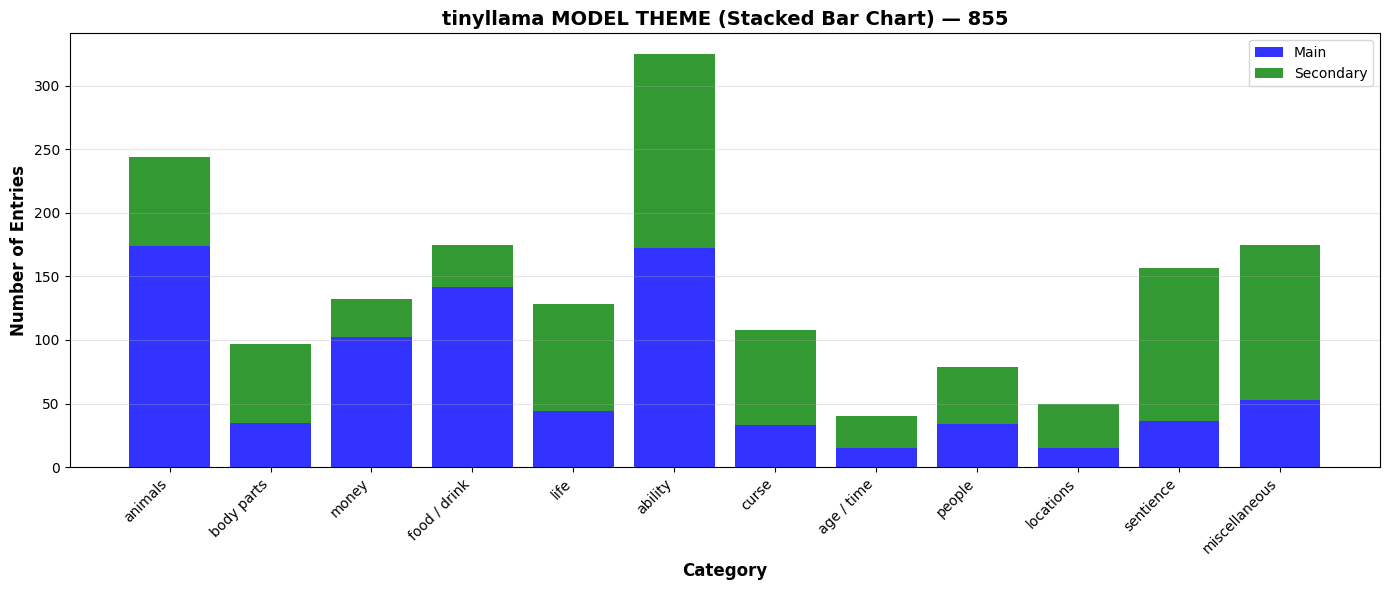

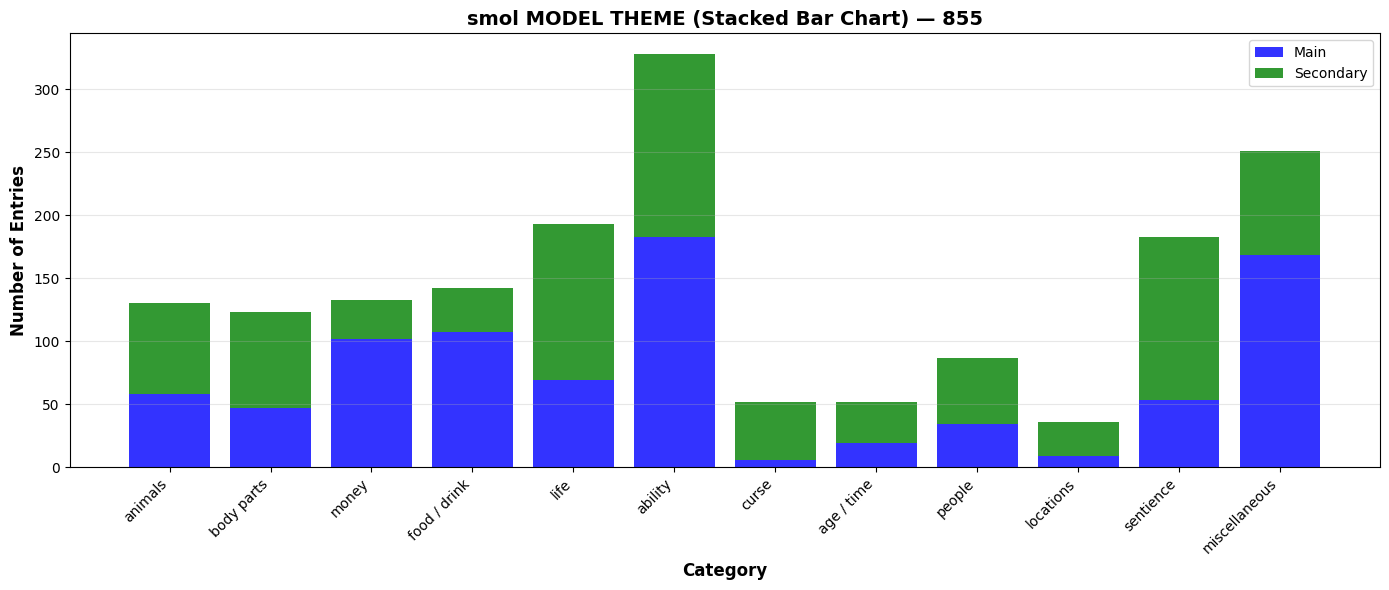

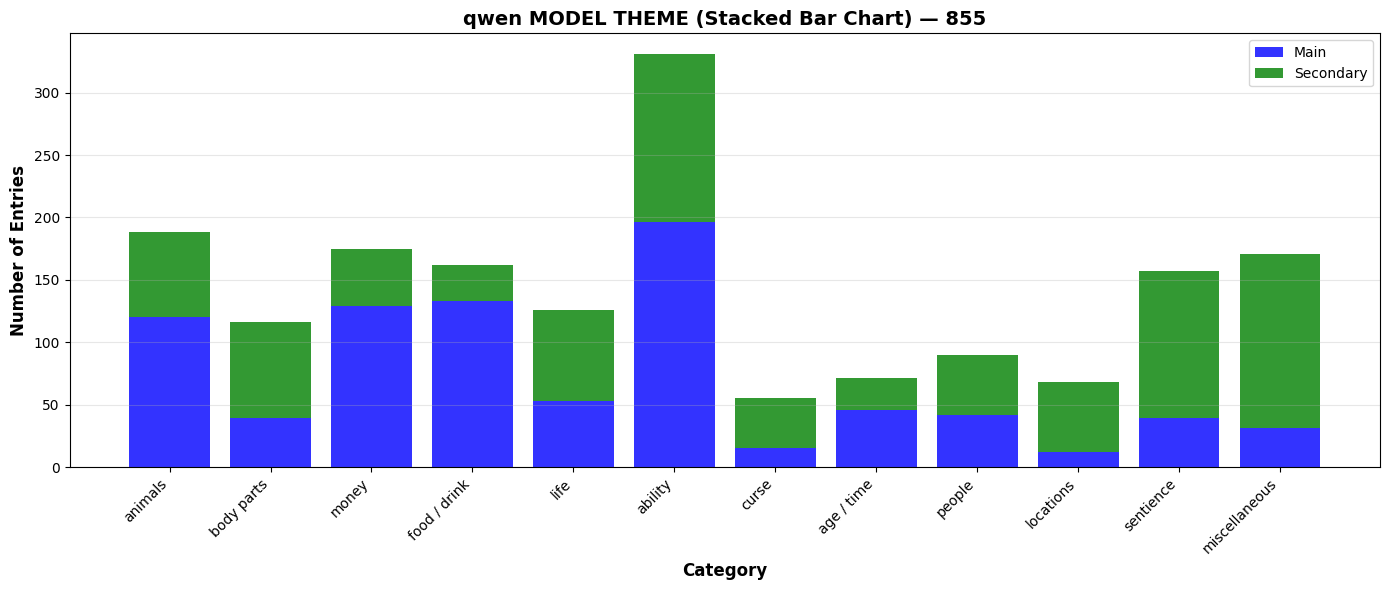

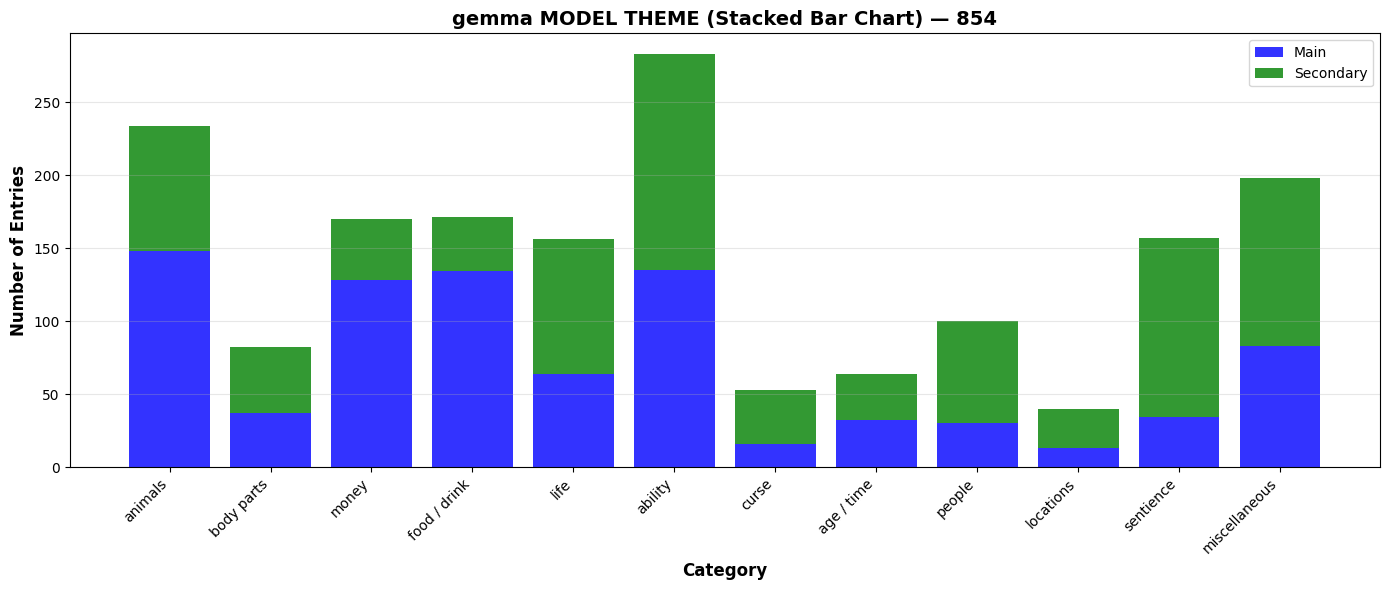

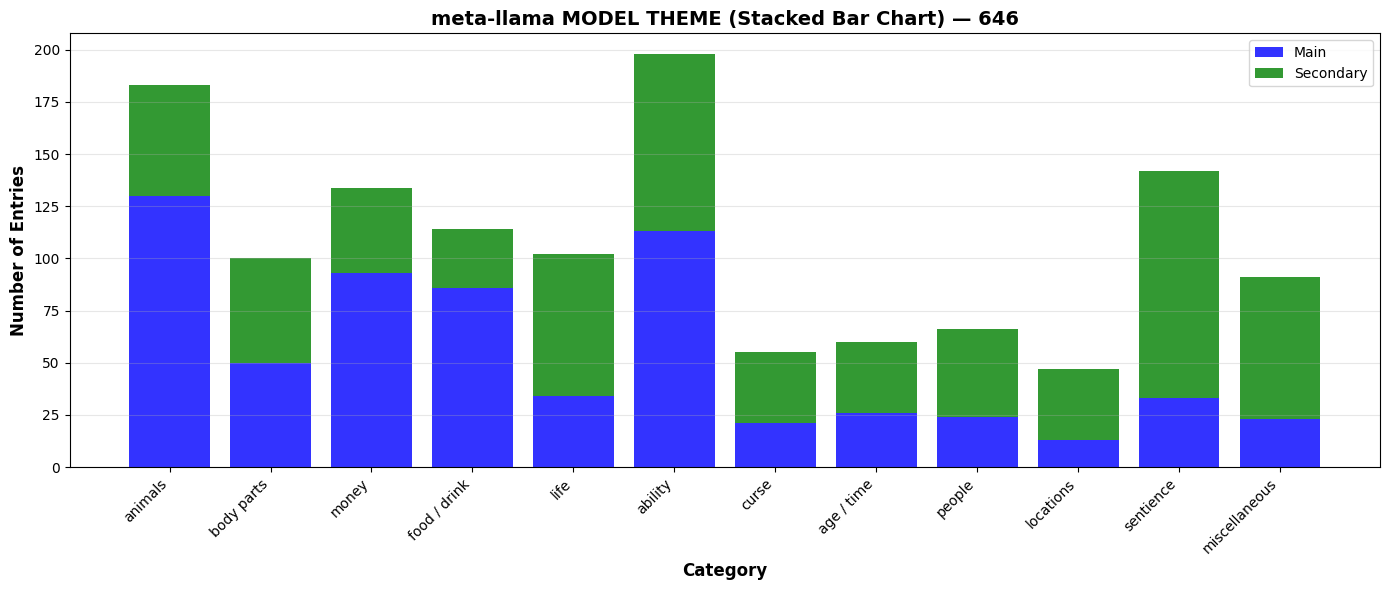

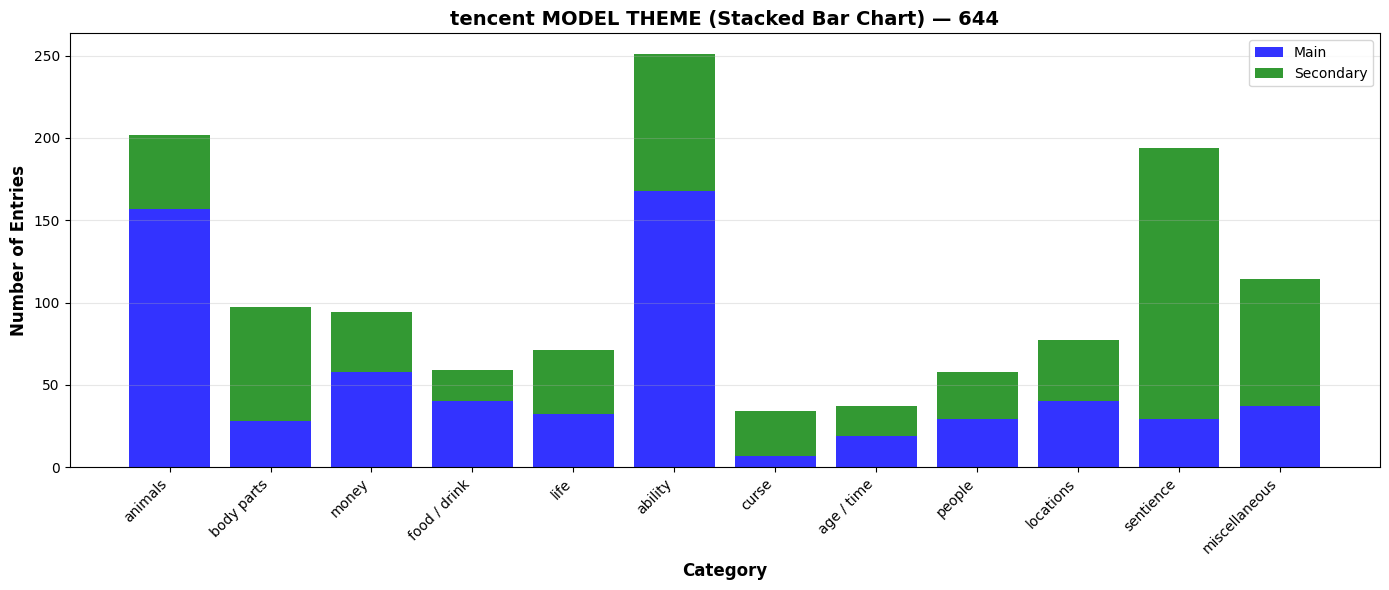

In [13]:
for model, dat in CAT_PAIRS.items():
    vis_data_cat(dat, model)

## 7 · Stacked Bar — All Models by Category
Horizontal chart: **Y-axis** = categories, **X-axis** = question count, each model colour-coded.

In [14]:
CAT_PAIRS['original'] = OG_CAT_PAIRS

In [15]:
def vis_stacked_all_models(cat_pairs):
    categories    = list(CATEGORIES.keys())
    models        = sorted(cat_pairs.keys())
    palette       = plt.cm.tab10.colors
    model_colours = {m: palette[i % len(palette)] for i, m in enumerate(models)}

    counts = {m: {c: 0 for c in categories} for m in models}
    for model, entries in cat_pairs.items():
        for e in entries:
            counts[model][e["main_category"]] += 1

    fig, ax = plt.subplots(figsize=(10, max(5, len(categories) * 0.55)))
    lefts   = [0] * len(categories)

    models_sort = sorted(models, key=lambda x: (x == 'original',x[0]), reverse=True)

    for model in models_sort:
        values = [counts[model][c] for c in categories]
        bars   = ax.barh(
            categories, values, left=lefts,
            label=model, color=model_colours[model],
            edgecolor="white", height=0.7,
        )
        for bar_patch, val in zip(bars, values):
            if val > 0:
                ax.text(
                    bar_patch.get_x() + bar_patch.get_width() / 2,
                    bar_patch.get_y() + bar_patch.get_height() / 2,
                    str(val), ha="center", va="center",
                    fontsize=7, color="white", fontweight="bold",
                )
        lefts = [l + v for l, v in zip(lefts, values)]

    ax.invert_yaxis()
    ax.set_xlabel("Number of questions", fontsize=11)
    ax.set_ylabel("Category",            fontsize=11)
    ax.set_title("Questions per category by model", fontsize=13, fontweight="bold")
    ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    plt.savefig(f'graphs/STACKED_BY_MODEL-{TIME}.png', dpi=300, bbox_inches='tight')
    plt.show()

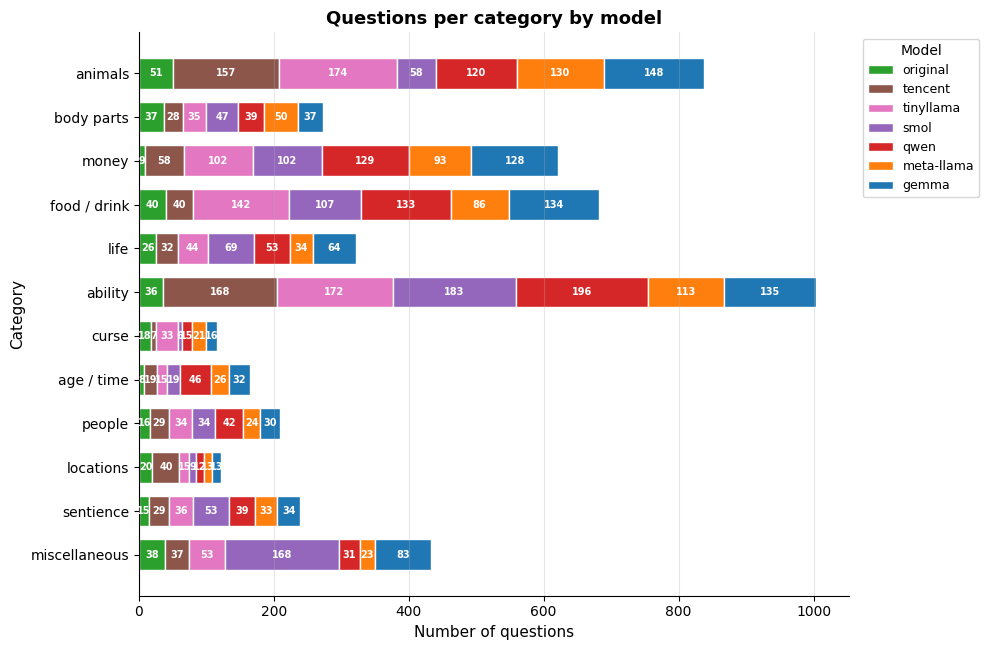

In [16]:
vis_stacked_all_models(CAT_PAIRS)

## 8 · Load Moderation Data
Reads upvoted, downvoted, and flagged questions from the JSON files produced by `proc_moderate_data.py`.

In [17]:
with open("upvote_questions.json", 'r') as f:
    upvote_dat = json.load(f)

with open("bad_questions.json", 'r') as f:
    bad_dat      = json.load(f)
    downvote_dat = bad_dat['downvotes']
    flagged_dat  = bad_dat['flagged']

print(f"Upvotes : {len(upvote_dat):,}")
print(f"Downvotes: {len(downvote_dat):,}")
print(f"Flagged : {len(flagged_dat):,}")

Upvotes : 141
Downvotes: 158
Flagged : 19


## 9 · Categorise Moderation Data

In [18]:
def categorize_mod_list(records):
    result = []
    for u in records:
        c = categorize_pairing({'a': u['optionA'], 'b': u['optionB']})
        c['model'] = "tinyllama" if u['MODEL'] == "llama" else u['MODEL']
        result.append(c)
    return result

upvote_cats   = categorize_mod_list(upvote_dat)
downvote_cats = categorize_mod_list(downvote_dat)
flagged_cats  = categorize_mod_list(flagged_dat)

print("Moderation data categorised.")

Moderation data categorised.


## 10 · Vote-Score Heatmaps
Score per `(category, model)` cell:  
`score = +3 × upvotes  −1 × downvotes  −3 × flags`  
Green = positive reception, red = negative.

In [19]:
def vote_score_dataframe(ups, downs, flags):
    y_axis   = sorted(CATEGORIES.keys())
    x_axis   = sorted(ALL_MODELS)
    arr_main = np.zeros((len(y_axis), len(x_axis)))
    arr_sec  = np.zeros((len(y_axis), len(x_axis)))

    for records, score in [(ups, 3), (downs, -1), (flags, -3)]:
        for u in records:
            model = u['model']
            if model not in x_axis:
                continue
            mi = x_axis.index(model)
            arr_main[y_axis.index(u['main_category'])][mi]      += score
            arr_sec [y_axis.index(u['secondary_category'])][mi] += score

    return (
        pd.DataFrame(arr_main, index=y_axis, columns=x_axis),
        pd.DataFrame(arr_sec,  index=y_axis, columns=x_axis),
    )

In [20]:
main_df, sec_df = vote_score_dataframe(upvote_cats, downvote_cats, flagged_cats)
main_df

,gemma,meta-llama,qwen,smol,tencent,tinyllama
ability,43.0,-4.0,22.0,-1.0,2.0,22.0
age / time,-5.0,6.0,-7.0,0.0,-1.0,-1.0
animals,12.0,9.0,9.0,8.0,-3.0,31.0
body parts,-6.0,2.0,2.0,2.0,5.0,4.0
curse,2.0,0.0,0.0,0.0,0.0,3.0
food / drink,1.0,-3.0,5.0,4.0,-2.0,1.0
life,0.0,3.0,-1.0,6.0,-3.0,3.0
locations,0.0,0.0,-2.0,-1.0,0.0,0.0
miscellaneous,-2.0,5.0,0.0,-3.0,0.0,-1.0
money,-9.0,1.0,-3.0,-7.0,-4.0,27.0


In [21]:
def showHeatmap(m, title):
    stoplight = seaborn.color_palette("blend:#ff0000,#fff,#00ff00", as_cmap=True)
    fig, ax   = plt.subplots(figsize=(12, 8))
    seaborn.heatmap(
        m, annot=True, cmap=stoplight, center=0,
        vmin=m.min().min(), vmax=m.max().max(), ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("MODELS")
    ax.set_ylabel("CATEGORIES")
    fig.tight_layout()
    fig.savefig(f"graphs/HEATMAP-{title}-{TIME}.png", dpi=300, bbox_inches='tight')
    plt.show()

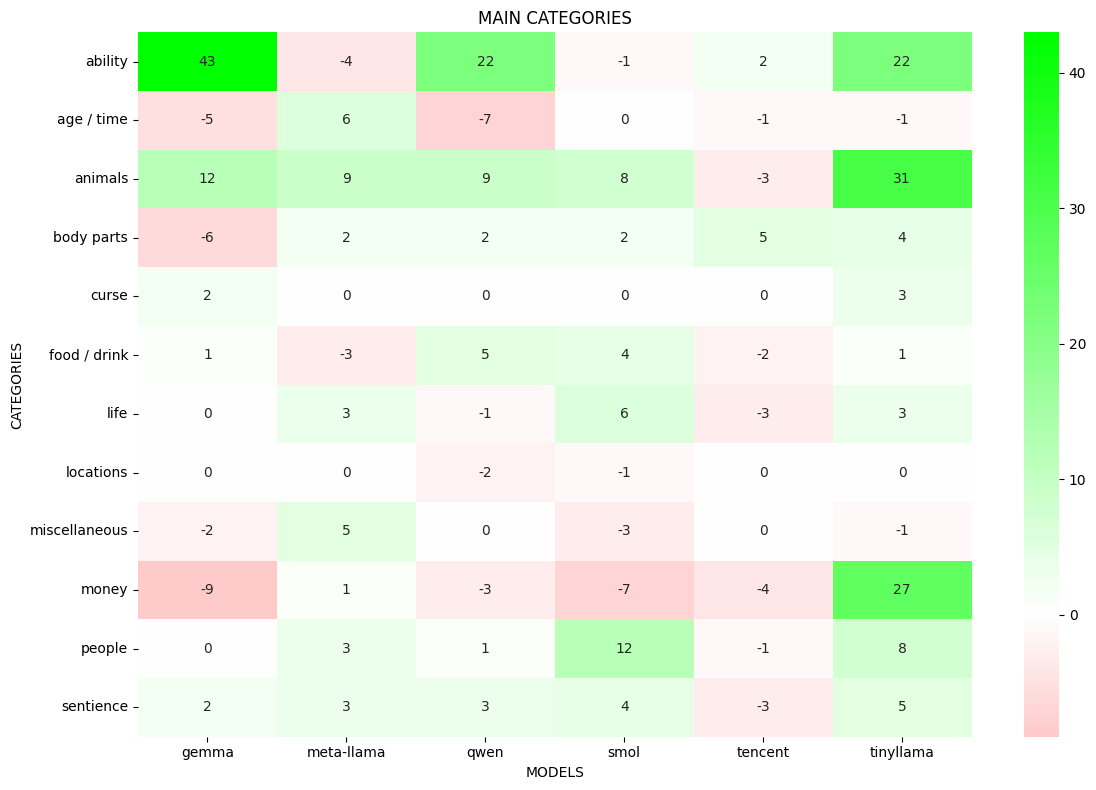

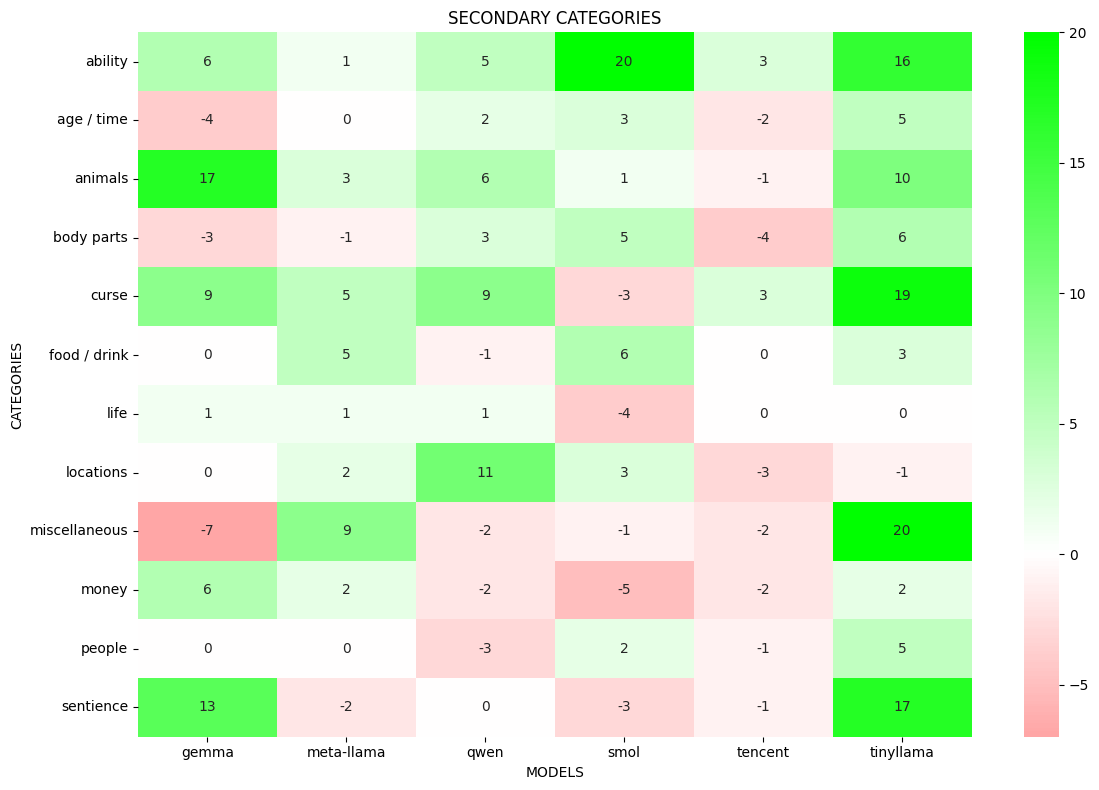

In [22]:
showHeatmap(main_df, "MAIN CATEGORIES")
showHeatmap(sec_df,  "SECONDARY CATEGORIES")

## Show divisive votes

In [23]:
# get all the questions that have at least 2 votes (grouped by category)
# divisive = at least one vote on each option
# unanimous = all votes on one option

# two pie graphs: one shows percentage of categories with unanimous votes, the other shows percentage of categories with divisive votes

In [24]:
CAT_PAIRS['tencent'][:5]

[{'a': 'Be able to walk without any motor force',
  'b': 'Get into a machine that forces your hand over 15 times',
  'votes_a': 1.0,
  'votes_b': 2.0,
  'main_category': 'ability',
  'secondary_category': 'body parts',
  'score': 0.6979},
 {'a': 'Always be the worst (but always have some good stuff)',
  'b': 'Be able to solve anything',
  'votes_a': 0.0,
  'votes_b': 2.0,
  'main_category': 'ability',
  'secondary_category': 'miscellaneous',
  'score': 0.6706},
 {'a': 'Be an animal',
  'b': 'be a bird',
  'votes_a': 0.0,
  'votes_b': 0.0,
  'main_category': 'animals',
  'secondary_category': 'sentience',
  'score': 0.7771},
 {'a': '3x4 speed',
  'b': 'Speed of a car',
  'votes_a': 1.0,
  'votes_b': 0.0,
  'main_category': 'age / time',
  'secondary_category': 'miscellaneous',
  'score': 0.6437},
 {'a': 'Be the only one that can walk',
  'b': 'Only be able to swim',
  'votes_a': 0.0,
  'votes_b': 1.0,
  'main_category': 'ability',
  'secondary_category': 'body parts',
  'score': 0.7324}

In [28]:
# organize categories by divisiveness
def vote_balance(dat):
    divisive = {'main':{}, 'secondary':{}}
    unanimous = {'main':{}, 'secondary':{}}
    total_votes = {'main':{}, 'secondary':{}}
    for c in CATEGORIES.keys():
        divisive['main'][c] = 0
        divisive['secondary'][c] = 0
        unanimous['main'][c] = 0
        unanimous['secondary'][c] = 0
        total_votes['main'][c] = 0
        total_votes['secondary'][c] = 0


    for m, d in dat.items():
        if m == 'original':
            continue
        for e in d:
            if e['votes_a'] + e['votes_b'] < 2:
                continue


            total_votes['main'][e['main_category']] += 1
            total_votes['secondary'][e['secondary_category']] += 1
            vote_balance = 'uni' if e['votes_a'] == 0 or e['votes_b'] == 0 else 'div'
            if vote_balance == 'uni':
                unanimous['main'][e['main_category']] += 1
                unanimous['secondary'][e['secondary_category']] += 1
            else:
                divisive['main'][e['main_category']] += 1
                divisive['secondary'][e['secondary_category']] += 1

    
    return {'uni':unanimous, 'div':divisive, 'total':total_votes}

In [29]:
vb = vote_balance(CAT_PAIRS)

In [ ]:
plt.pie()

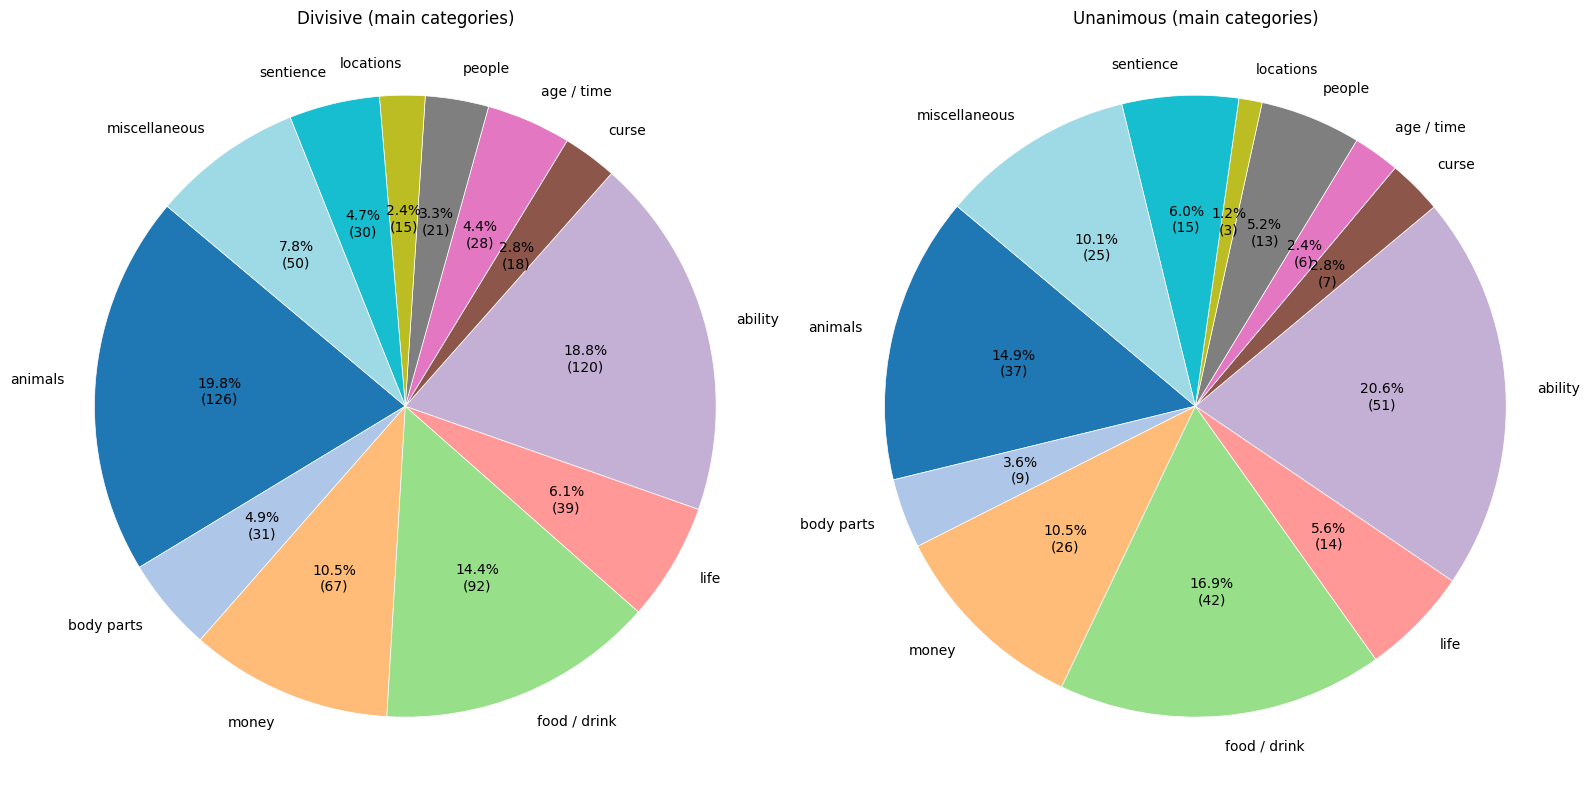

In [36]:
# Pie charts: divisive vs unanimous (main categories only)
categories = list(CATEGORIES.keys())

div_vals = [vb['div']['main'][c] for c in categories]
uni_vals = [vb['uni']['main'][c] for c in categories]

def _plot_pie(ax, vals, cats, title):
    total = sum(vals)
    if total == 0:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", fontsize=12)
        ax.set_title(title)
        ax.axis('off')
        return
    labels = [f"{c}" for c, v in zip(cats, vals) if v > 0]
    data   = [v for v in vals if v > 0]
    colors = plt.cm.tab20(np.linspace(0, 1, len(data)))
    def autopct(p):
        count = int(round(p * total / 100.0))
        return f"{p:.1f}%\n({count})"
    ax.pie(data, labels=labels, colors=colors, autopct=autopct, startangle=140, wedgeprops={'linewidth':0.5, 'edgecolor':'white'})
    ax.set_title(title)
    ax.axis('equal')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
_plot_pie(axes[0], div_vals, categories,    "Divisive (main categories)")
_plot_pie(axes[1], uni_vals, categories,    "Unanimous (main categories)")
fig.tight_layout()
fig.savefig(f"graphs/PIES_DIV_VS_UNI-{TIME}.png", dpi=300, bbox_inches='tight')
plt.show()

## TODO 
make stacked horizontal bar graph that shows percentage of unanswered / 1 vote, unanimous, and divisive questions per category; and model